# Project 2: Student Exam Performance

## 1. Introduction
### 1.1 Dataset Description

This dataset shows the student-related academic, lifestyle, and socio-enconmic factores that include exam perdormance. It include study hours, student attendence, sleep hours, motivation, tutoring sessions, parental involvement, school type and other environmental features. The main target varibale is Exam_Score which represents the student final exam score.

- Rows: 6607
- Columns: 20

### 1.2 Analysis Approach

This project analyzes student exam performance by grouping related features into meaningful categories and exploring their collective impact on exam scores using EDA. The goal is to uncover key factors influencing performance and provide actionable insights for improvement.

### 1.3 Feature Grouping
To better understand the factors affecting student performance, the features were grouped into the following categories:

- Study Behavior: Hours_Studied, Motivation_Level, Previous_Scores, Attendance
- Learning Resources: Access_to_Resources, Internet_Access, Tutoring_Sessions
- Health & Lifestyle: Sleep_Hours, Physical_Activity
- Family Factors: Parental_Involvement, Family_Income, Parental_Education_Level
- Social Factors: Peer_Influence, Extracurricular_Activities
- School Factors: School_Type, Teacher_Quality, Distance_from_Home
- Personal Factors: Gender, Learning_Disabilities

## 2. Setup

In [20]:
# standard libraries
from pathlib import Path

# installed libraries
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# configuration
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 3. Data Loading

[Dataset Hosted at: Kaggle | by Muhammad Shoaib](https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis) 

In [3]:
# Download latest version
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\grandmaster07\student-exam-performance-dataset-analysis\versions\1


In [11]:
dataset_path = next(Path(path).glob('*.csv'))
student = pd.read_csv(dataset_path)

## 4. Data Understanding

In [ ]:
# display the first 5 rows to understand the structure of the data, column names, and initial values
student.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# display the last 5 rows check if there are any unusual values or issues at the end of the file
student.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [14]:
# display column names as a list
student.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [15]:
# check the shape of the dataset (rows, columns) to know how many samples and features we have
student.shape

(6607, 20)

In [ ]:
# get the total number of elements in the dataset (rows × columns), it gives an idea of the dataset's overall size
student.size

132140

In [ ]:
# display basic information about the dataset like number of rows, columns, data types, and if there are missing values.
student.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [17]:
# summary statistics for numerical columns to understand the distribution, central tendency, and detect possible outliers.
student.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Key Observations
- The dataset contains 6607 rows and 20 columns, indicating a suitable data size for exploratory analysis.

- Most columns have no missing values, except for some features such as:
    `Teacher Quality`
    `Parents' Education Level`
    `Distance from Home`
    These features must be handled before deeper analysis.

- The dataset includes a mix of numerical and categorical features, requiring different analysis techniques for each type.

- The target variable, "Exam Score," has a range of approximately 55 to 101.

- The average values ​​indicate:
    - Students study for approximately 20 hours
    - Average attendance is approximately 80%
    - Average sleep is approximately 7 hours

## 5. Data Cleaning

### 5.1 Handling Missing Values

In [ ]:
# check for missing values in each column
student.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [ ]:
# drop rows with missing values 
student = student.dropna()

### 5.2 Handling Duplicated Rows

In [19]:
# check for duplicated rows in the dataset
student.duplicated().sum()

np.int64(0)

There are no duplicate rows that need to be handl.

## 6. Exploratory Data Analysis (EDA)

### 6.1 Study Behavior

#### How do study hours affect exam performance?

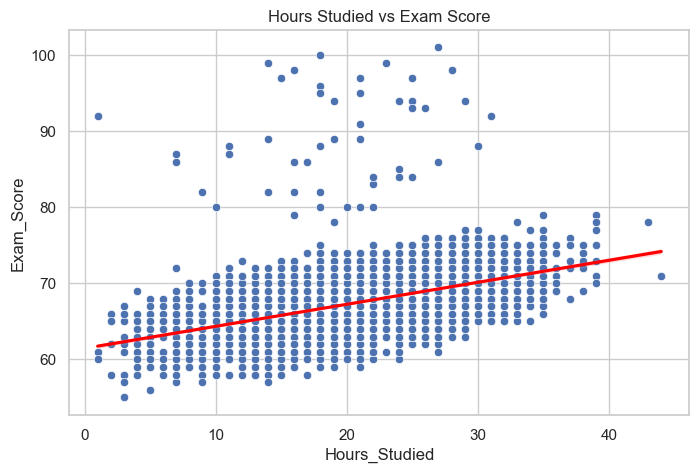

In [30]:
sns.scatterplot(data=student, x='Hours_Studied', y='Exam_Score')
sns.regplot(data=student, x='Hours_Studied', y='Exam_Score', scatter=False, color='red')

plt.title('Hours Studied vs Exam Score')
plt.show()

#### Does attendance have a significant impact on exam scores?

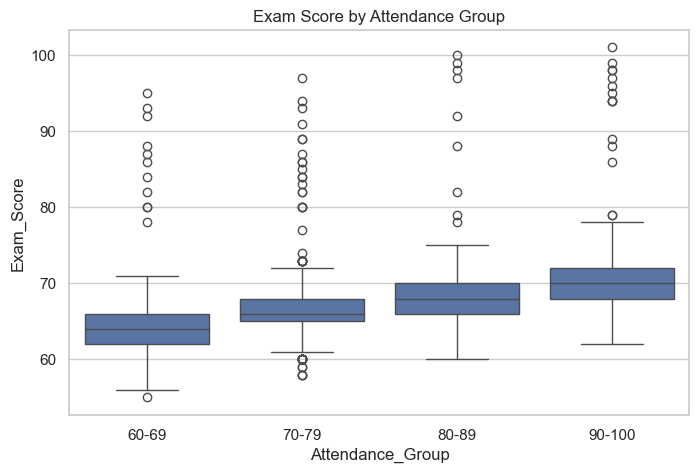

In [32]:
student['Attendance_Group'] = pd.cut(
    student['Attendance'],
    bins=[59, 69, 79, 89, 100],
    labels=['60-69', '70-79', '80-89', '90-100']
)

sns.boxplot(data=student, x='Attendance_Group', y='Exam_Score')

plt.title('Exam Score by Attendance Group')
plt.show()

#### Is previous academic performance a strong predictor of current results?

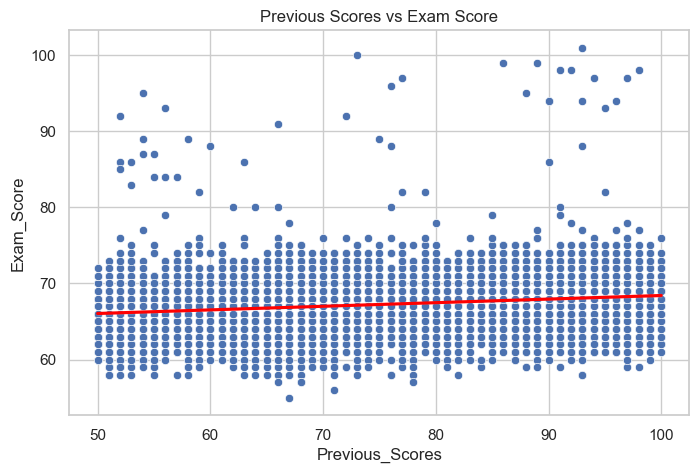

In [33]:
sns.scatterplot(data=student, x='Previous_Scores', y='Exam_Score')
sns.regplot(data=student, x='Previous_Scores', y='Exam_Score', scatter=False, color='red')

plt.title('Previous Scores vs Exam Score')
plt.show()

#### How does motivation level influence student performance?

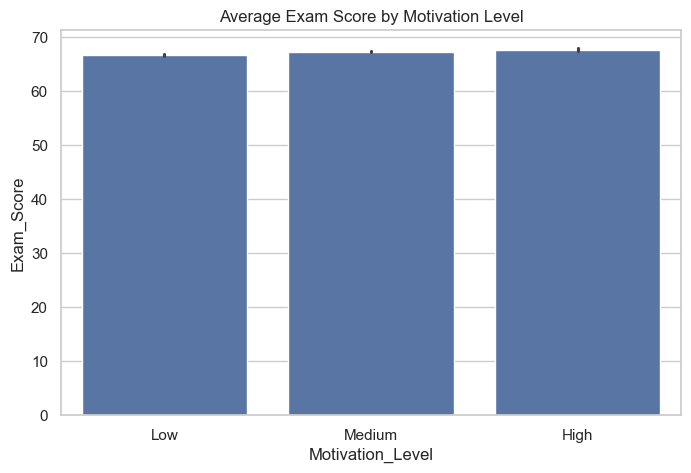

In [36]:
sns.barplot(data=student, x='Motivation_Level', y='Exam_Score')

plt.title('Average Exam Score by Motivation Level')
plt.show()

#### Key Observations

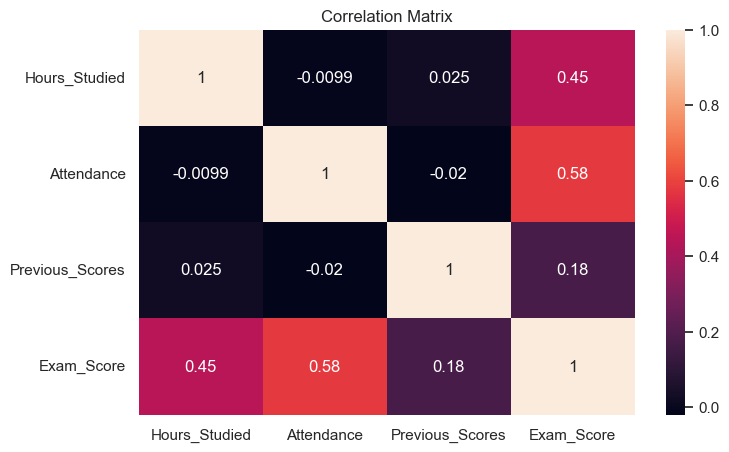

In [38]:
sns.heatmap(
    student[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score']].corr(),
    annot=True
)

plt.title('Correlation Matrix')
plt.show()

- There is a positive relationship between study hours and exam performance, with increased study time generally leading to higher scores.

- Attendance shows the strongest effect on exam performance among study behavior traits, with a correlation coefficient of 0.58, suggesting that regular attendance is a key factor for success.

- Prior academic performance is weaker (0.18) than current exam scores, indicating that past results are not a strong predictor on their own.

- Motivation level shows only a slight difference in performance between groups, suggesting that motivation alone is insufficient without regular study habits.

- Overall, current behavior (attendance and study habits) appears to have a greater impact than past performance.

### 6.2 Learning Resources

#### How does access to learning resources affect exam performance?

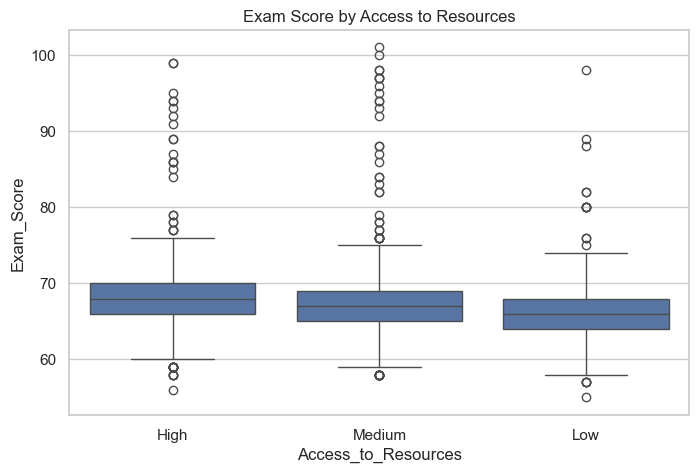

In [39]:
sns.boxplot(data=student, x='Access_to_Resources', y='Exam_Score')

plt.title('Exam Score by Access to Resources')
plt.show()

#### Does internet access impact student performance?

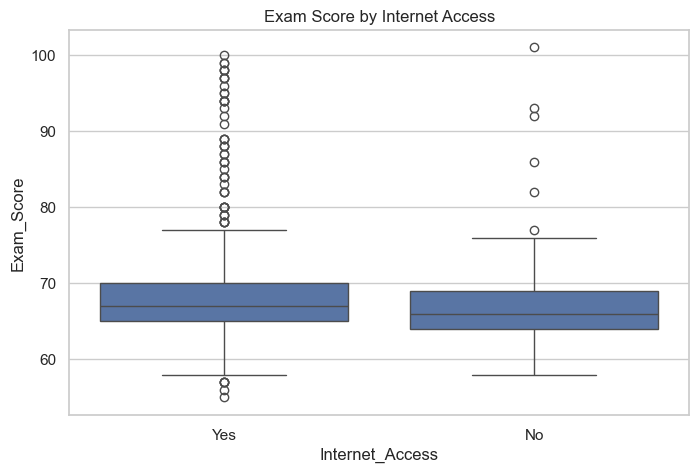

In [40]:
sns.boxplot(data=student, x='Internet_Access', y='Exam_Score')

plt.title('Exam Score by Internet Access')
plt.show()

#### Do tutoring sessions improve exam scores?

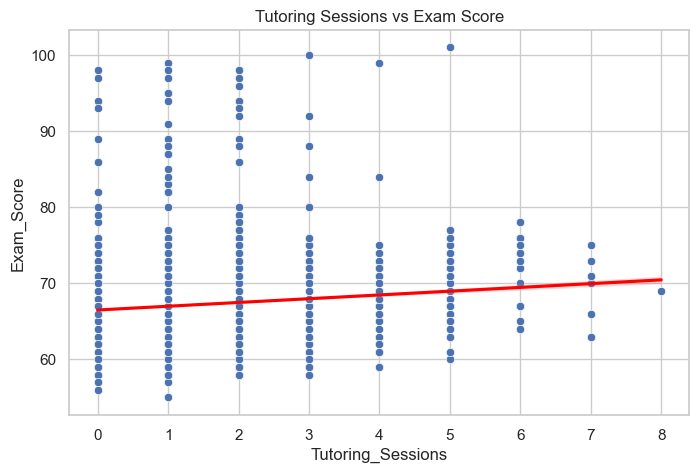

In [41]:
sns.scatterplot(data=student, x='Tutoring_Sessions', y='Exam_Score')
sns.regplot(data=student, x='Tutoring_Sessions', y='Exam_Score', scatter=False, color='red')

plt.title('Tutoring Sessions vs Exam Score')
plt.show()

In [43]:
student[['Tutoring_Sessions', 'Exam_Score']].corr()

,Tutoring_Sessions,Exam_Score
Tutoring_Sessions,1.000000,0.156525
Exam_Score,0.156525,1.000000


#### Key Observations

- Students with higher access to resources tend to achieve slightly better exam scores.
- Internet access shows a small positive impact on performance, with only minor differences between groups.
- Tutoring sessions have a weak positive relationship with exam scores (correlation ≈ 0.15), and the scores vary widely regardless of the number of sessions.
- Overall, learning resources provide supportive benefits, but their impact is weaker compared to study behavior factors.

### 6.3 Health & Lifestyle

#### How do sleep hours affect exam performance?

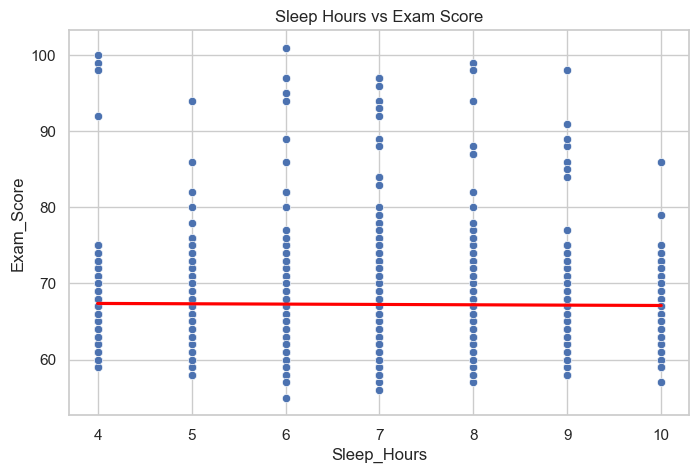

In [44]:
sns.scatterplot(data=student, x='Sleep_Hours', y='Exam_Score')
sns.regplot(data=student, x='Sleep_Hours', y='Exam_Score', scatter=False, color='red')

plt.title('Sleep Hours vs Exam Score')
plt.show()

#### Does physical activity influence exam performance?

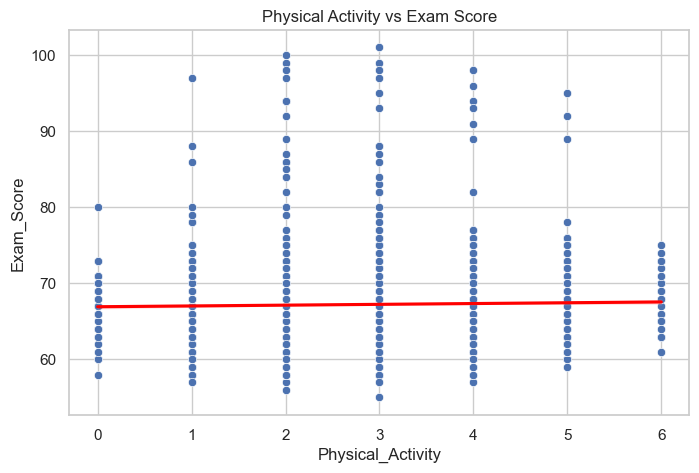

In [45]:
sns.scatterplot(data=student, x='Physical_Activity', y='Exam_Score')
sns.regplot(data=student, x='Physical_Activity', y='Exam_Score', scatter=False, color='red')

plt.title('Physical Activity vs Exam Score')
plt.show()

#### Key Observations

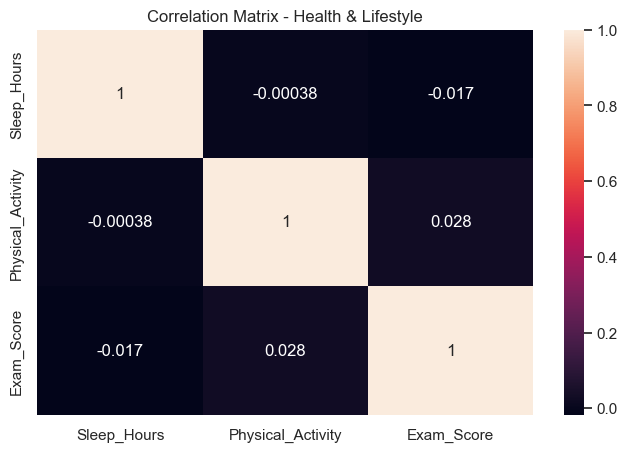

In [46]:
sns.heatmap(
    student[['Sleep_Hours', 'Physical_Activity', 'Exam_Score']].corr(),
    annot=True
)

plt.title('Correlation Matrix - Health & Lifestyle')
plt.show()

- Correlation values are close to zero (Sleep ≈ -0.01, Activity ≈ 0.03), confirming negligible influence.
- Health & lifestyle factors show almost no significant impact on exam performance.

### 6.4 Family Factors

### 6.5 Social Factors

### 6.6 School Factors

### 6.7 Personal Factors